# Customer Churn Prediction — Data Mining Project

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, accuracy_score,
    roc_curve, roc_auc_score
)

from sklearn.ensemble import (
    GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')


## 2. Load Data

In [2]:
# Option A: load from Kaggle Hub
import kagglehub
path = kagglehub.dataset_download('miadul/customer-churn-prediction-business-dataset')
csv_file = os.path.join(path, os.listdir(path)[0])

data_raw = pd.read_csv(csv_file)
print(f'Shape: {data_raw.shape}')
data_raw.head()


Shape: (10000, 32)


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


## 3. Exploratory Data Analysis

In [3]:
print('=== DATA TYPES ===')
print(data_raw.dtypes)
print(f'\n=== MISSING VALUES ===')
print(data_raw.isnull().sum())


=== DATA TYPES ===
customer_id                   str
gender                        str
age                         int64
country                       str
city                          str
customer_segment              str
tenure_months               int64
signup_channel                str
contract_type                 str
monthly_logins              int64
weekly_active_days          int64
avg_session_time          float64
features_used               int64
usage_growth_rate         float64
last_login_days_ago         int64
monthly_fee                 int64
total_revenue               int64
payment_method                str
payment_failures            int64
discount_applied              str
price_increase_last_3m        str
support_tickets             int64
avg_resolution_time       float64
complaint_type                str
csat_score                float64
escalations                 int64
email_open_rate           float64
marketing_click_rate      float64
nps_score                   i

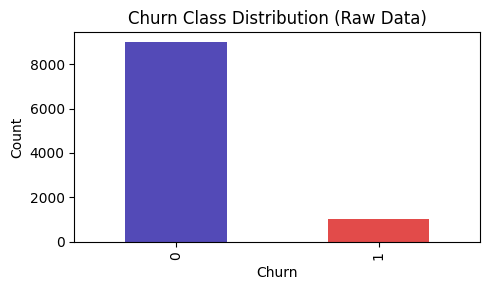

churn
0    0.8979
1    0.1021
Name: proportion, dtype: float64


In [4]:
# Class balance
fig, ax = plt.subplots(figsize=(5, 3))
data_raw['churn'].value_counts().plot(kind='bar', ax=ax, color=['#534AB7', '#E24B4A'])
ax.set_title('Churn Class Distribution (Raw Data)')
ax.set_xlabel('Churn')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print(data_raw['churn'].value_counts(normalize=True))


In [5]:
# Statistical summary
display(data_raw.describe())

# Unique values in categorical columns
for col in data_raw.select_dtypes(include=['object', 'str']).columns:
    print(f'{col}: {data_raw[col].nunique()} unique values')


,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


customer_id: 10000 unique values
gender: 2 unique values
country: 7 unique values
city: 7 unique values
customer_segment: 3 unique values
signup_channel: 3 unique values
contract_type: 3 unique values
payment_method: 3 unique values
discount_applied: 2 unique values
price_increase_last_3m: 2 unique values
complaint_type: 3 unique values
survey_response: 3 unique values


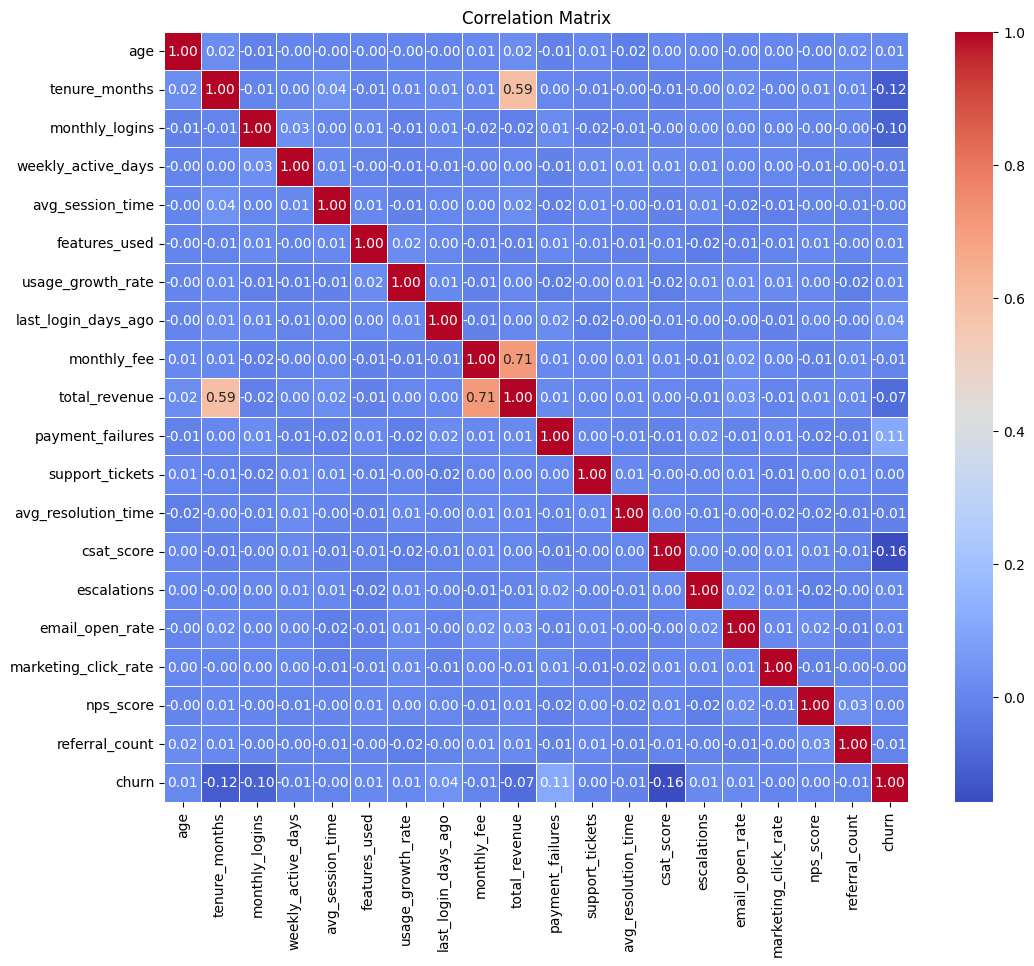

churn                   1.000000
payment_failures        0.112494
last_login_days_ago     0.037250
email_open_rate         0.011506
age                     0.010155
escalations             0.009561
features_used           0.005435
usage_growth_rate       0.005276
nps_score               0.002996
support_tickets         0.000317
marketing_click_rate   -0.002068
avg_session_time       -0.004659
monthly_fee            -0.005048
referral_count         -0.007323
weekly_active_days     -0.008818
avg_resolution_time    -0.009172
total_revenue          -0.070120
monthly_logins         -0.098339
tenure_months          -0.117014
csat_score             -0.157924
Name: churn, dtype: float64


In [27]:
corr_matrix = data_raw.select_dtypes(include=['number']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()
print(corr_matrix['churn'].sort_values(ascending=False))

In [7]:
# Percentage difference between churners vs non-churners
churn_summary = data_raw.groupby('churn').mean(numeric_only=True)
differences = (churn_summary.loc[1] / churn_summary.loc[0]) - 1
print('Percentage difference in features for Churners vs Non-Churners:')
print(differences.sort_values())


Percentage difference in features for Churners vs Non-Churners:
total_revenue          -0.218511
tenure_months          -0.214336
monthly_logins         -0.159768
csat_score             -0.144232
referral_count         -0.024166
weekly_active_days     -0.019232
avg_resolution_time    -0.012576
monthly_fee            -0.011339
avg_session_time       -0.006916
marketing_click_rate   -0.003784
support_tickets         0.000960
features_used           0.007961
age                     0.012011
email_open_rate         0.017647
nps_score               0.020201
escalations             0.058669
last_login_days_ago     0.128494
usage_growth_rate       0.136037
payment_failures        0.558016
dtype: float64


In [8]:
# Outlier count per feature (IQR method)
numeric_cols = data_raw.select_dtypes(include='number').columns.drop('churn')
outlier_counts = {}
for col in numeric_cols:
    Q1 = data_raw[col].quantile(0.25)
    Q3 = data_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_counts[col] = ((data_raw[col] < Q1 - 1.5*IQR) | (data_raw[col] > Q3 + 1.5*IQR)).sum()
print('Outlier Count per Feature:')
print(pd.Series(outlier_counts).sort_values(ascending=False))


Outlier Count per Feature:
total_revenue           513
monthly_fee             513
last_login_days_ago     471
csat_score              221
payment_failures        147
features_used           121
usage_growth_rate        78
monthly_logins           49
escalations              43
avg_resolution_time      38
nps_score                36
avg_session_time         27
support_tickets          18
referral_count            8
age                       0
tenure_months             0
weekly_active_days        0
marketing_click_rate      0
email_open_rate           0
dtype: int64


## 4. Helper: Build & Train All Models

This reusable function builds all 10 models with the same hyperparameters and trains/evaluates them on any given train/test split.

In [9]:
def build_models(pos_weight):
    """Return a fresh dict of all 10 models with original hyperparameters."""
    balanced_base = DecisionTreeClassifier(max_depth=5, class_weight='balanced')
    return {
        'GradientBoosting': GradientBoostingClassifier(
            n_estimators=150, learning_rate=0.02,
            max_depth=4, subsample=0.8, random_state=42
        ),
        'AdaBoost': AdaBoostClassifier(
            estimator=balanced_base,
            n_estimators=50, learning_rate=0.1, random_state=42
        ),
        'SVM': SVC(
            kernel='rbf', C=0.4, gamma='auto',
            class_weight='balanced', probability=True, random_state=42
        ),
        'LogisticRegression': LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42
        ),
        'DecisionTree': DecisionTreeClassifier(
            max_depth=10, class_weight='balanced', random_state=42
        ),
        'RandomForest': RandomForestClassifier(
            n_estimators=7, max_depth=9,
            class_weight='balanced', random_state=42, n_jobs=-1
        ),
        'KNN': KNeighborsClassifier(
            n_neighbors=20, weights='distance', metric='minkowski', p=2
        ),
        'NaiveBayes': GaussianNB(var_smoothing=0.0000001),
        'MLP': MLPClassifier(
            hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
            alpha=0.001, batch_size=32, learning_rate_init=0.001,
            max_iter=500, early_stopping=True, n_iter_no_change=20, random_state=42
        ),
        'XGBoost': XGBClassifier(
            n_estimators=400, max_depth=3, learning_rate=0.03,
            subsample=0.7, colsample_bytree=0.8, gamma=1,
            reg_alpha=0.5, reg_lambda=1,
            scale_pos_weight=pos_weight,
            eval_metric='aucpr', random_state=42
        ),
    }


def train_and_evaluate(models, x_train, x_test, y_train, y_test, x_train_scaled, x_test_scaled):
    """Train all models and print classification reports. Returns trained models dict."""
    weights = compute_sample_weight(class_weight='balanced', y=y_train)
    for name, model in models.items():
        if name == 'GradientBoosting':
            model.fit(x_train, y_train, sample_weight=weights)
        elif name == 'SVM':
            model.fit(x_train_scaled, y_train)
        else:
            model.fit(x_train, y_train)
        preds = model.predict(x_test_scaled if name == 'SVM' else x_test)
        print(f'\n── {name} ──')
        print(f'Accuracy: {accuracy_score(y_test, preds):.4f}')
        print(classification_report(y_test, preds, target_names=['No Churn', 'Churn'], zero_division=0))
    return models


def plot_roc(models, x_test, x_test_scaled, y_test, title):
    """Plot ROC curves for all models."""
    colors = [
        '#534AB7', '#0F6E56', '#993C1D', '#993556', '#3B6D11',
        '#185FA5', '#BA7517', '#A32D2D', '#888780', '#1D9E75'
    ]
    plt.figure(figsize=(11, 8))
    for (name, model), color in zip(models.items(), colors):
        x_eval = x_test_scaled if name == 'SVM' else x_test
        y_probs = model.predict_proba(x_eval)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        auc = roc_auc_score(y_test, y_probs)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})', color=color, linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)', linewidth=1.5)
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"roc_{title.replace(' ', '_').lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()


def plot_feature_importance(models, title):
    """Plot feature importance for all tree-based models."""
    tree_models = {k: v for k, v in models.items()
                   if hasattr(v, 'feature_importances_')}
    n = len(tree_models)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 6))
    if n == 1:
        axes = [axes]
    colors = ['#534AB7', '#0F6E56', '#993C1D', '#993556', '#3B6D11']
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    for ax, (name, model), color in zip(axes, tree_models.items(), colors):
        feature_names = np.array(model.feature_names_in_)
        importances = model.feature_importances_
        top_n = min(10, len(feature_names))
        idx = np.argsort(importances)[-top_n:]
        ax.barh(feature_names[idx], importances[idx], color=color, alpha=0.85, edgecolor='white')
        ax.set_title(name, fontsize=11, fontweight='bold')
        ax.set_xlabel('Importance', fontsize=9)
        ax.tick_params(axis='y', labelsize=8)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(f"feat_imp_{title.replace(' ', '_').lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()


## 5. Stage 1 — Before Cleaning (Raw Data)

Minimal preprocessing: drop `customer_id`, fill `complaint_type` NaN, encode categoricals, then train all models on the full feature set.

In [10]:
# ── Preprocessing (minimal — before outlier removal / feature selection) ──
data_s1 = data_raw.copy()
data_s1 = data_s1.drop(columns=['customer_id'])

# Fill only the known NaN column
data_s1['complaint_type'] = data_s1['complaint_type'].fillna('No Complaint')

# Encode categoricals
cat_cols = ['price_increase_last_3m', 'customer_segment', 'contract_type',
            'discount_applied', 'survey_response', 'gender',
            'complaint_type', 'payment_method']
le = LabelEncoder()
for col in cat_cols:
    data_s1[col] = le.fit_transform(data_s1[col].astype(str))

# Remaining string columns → get_dummies
data_s1 = pd.get_dummies(data_s1, drop_first=True)

print(f'Stage 1 shape: {data_s1.shape}')
print(f'Missing values: {data_s1.isnull().sum().sum()}')


Stage 1 shape: (10000, 42)
Missing values: 0


In [11]:
# ── Train/Test split ──
X_s1 = data_s1.drop(columns=['churn'])
y_s1 = data_s1['churn']

x_train_s1, x_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X_s1, y_s1, test_size=0.2, random_state=42, stratify=y_s1
)

scaler_s1 = StandardScaler()
x_train_s1_sc = scaler_s1.fit_transform(x_train_s1)
x_test_s1_sc  = scaler_s1.transform(x_test_s1)

pos_weight_s1 = (y_train_s1 == 0).sum() / (y_train_s1 == 1).sum()

print(f'Train: {x_train_s1.shape}  |  Test: {x_test_s1.shape}')
print(f'Churn rate in train: {y_train_s1.mean():.3f}')


Train: (8000, 41)  |  Test: (2000, 41)
Churn rate in train: 0.102


In [12]:
# ── Train & Evaluate — Stage 1 ──
models_s1 = build_models(pos_weight_s1)
models_s1 = train_and_evaluate(
    models_s1, x_train_s1, x_test_s1, y_train_s1, y_test_s1,
    x_train_s1_sc, x_test_s1_sc
)



── GradientBoosting ──
Accuracy: 0.7265
              precision    recall  f1-score   support

    No Churn       0.97      0.71      0.82      1796
       Churn       0.25      0.83      0.38       204

    accuracy                           0.73      2000
   macro avg       0.61      0.77      0.60      2000
weighted avg       0.90      0.73      0.78      2000


── AdaBoost ──
Accuracy: 0.7220
              precision    recall  f1-score   support

    No Churn       0.97      0.71      0.82      1796
       Churn       0.24      0.81      0.37       204

    accuracy                           0.72      2000
   macro avg       0.61      0.76      0.60      2000
weighted avg       0.90      0.72      0.78      2000


── SVM ──
Accuracy: 0.7300
              precision    recall  f1-score   support

    No Churn       0.94      0.74      0.83      1796
       Churn       0.21      0.62      0.32       204

    accuracy                           0.73      2000
   macro avg       0.58   

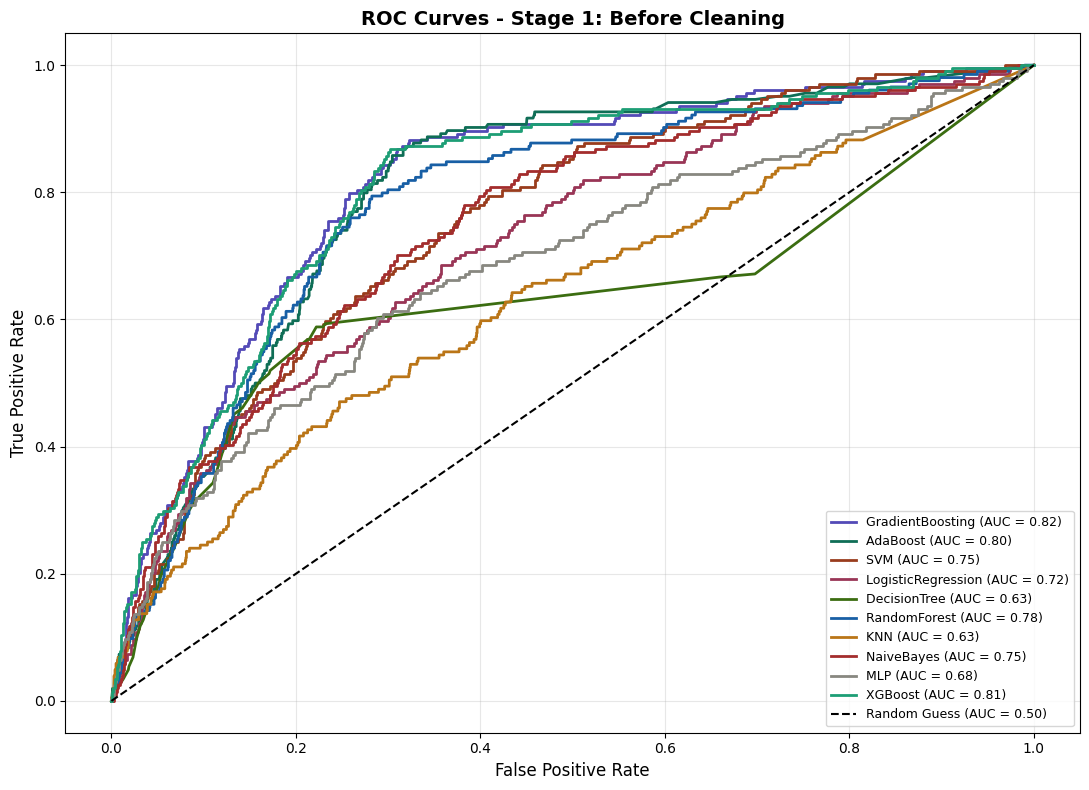

In [13]:
# ── ROC Curves — Stage 1: Before Cleaning ──
plot_roc(models_s1, x_test_s1, x_test_s1_sc, y_test_s1,
         'ROC Curves - Stage 1: Before Cleaning')


In [ ]:
# ── Feature Importance — Stage 1 ──
plot_feature_importance(models_s1, 'Feature Importance - Stage 1: Before Cleaning')


## 6. Stage 2 — After Outlier Removal

Remove outliers using IQR on the numeric columns, then re-train all models.

In [14]:
# ── Remove outliers from the full dataset before feature selection ──
data_s2 = data_raw.copy()
data_s2 = data_s2.drop(columns=['customer_id'])
data_s2['complaint_type'] = data_s2['complaint_type'].fillna('No Complaint')

# Encode categoricals
le2 = LabelEncoder()
for col in cat_cols:
    data_s2[col] = le2.fit_transform(data_s2[col].astype(str))

# IQR outlier removal on numeric columns
col_outliers = [
    'total_revenue', 'monthly_fee', 'last_login_days_ago', 'csat_score',
    'payment_failures', 'features_used', 'usage_growth_rate', 'monthly_logins',
    'escalations', 'avg_resolution_time', 'nps_score', 'avg_session_time',
    'support_tickets', 'referral_count'
]
print(f'Before outlier removal: {data_s2.shape}')
for col in col_outliers:
    if col in data_s2.columns:
        Q1 = data_s2[col].quantile(0.25)
        Q3 = data_s2[col].quantile(0.75)
        IQR = Q3 - Q1
        data_s2 = data_s2[(data_s2[col] >= Q1 - 1.5*IQR) & (data_s2[col] <= Q3 + 1.5*IQR)]
print(f'After outlier removal:  {data_s2.shape}')
print(f'Rows removed: {data_raw.shape[0] - data_s2.shape[0]}')

# get_dummies for remaining string cols
data_s2 = pd.get_dummies(data_s2, drop_first=True)


Before outlier removal: (10000, 31)
After outlier removal:  (8145, 31)
Rows removed: 1855


In [15]:
# ── Train/Test split ──
X_s2 = data_s2.drop(columns=['churn'])
y_s2 = data_s2['churn']

x_train_s2, x_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_s2, y_s2, test_size=0.2, random_state=42, stratify=y_s2
)

scaler_s2 = StandardScaler()
x_train_s2_sc = scaler_s2.fit_transform(x_train_s2)
x_test_s2_sc  = scaler_s2.transform(x_test_s2)

pos_weight_s2 = (y_train_s2 == 0).sum() / (y_train_s2 == 1).sum()

print(f'Train: {x_train_s2.shape}  |  Test: {x_test_s2.shape}')
print(f'Churn rate in train: {y_train_s2.mean():.3f}')


Train: (6516, 41)  |  Test: (1629, 41)
Churn rate in train: 0.093


In [16]:
# ── Train & Evaluate — Stage 2 ──
models_s2 = build_models(pos_weight_s2)
models_s2 = train_and_evaluate(
    models_s2, x_train_s2, x_test_s2, y_train_s2, y_test_s2,
    x_train_s2_sc, x_test_s2_sc
)



── GradientBoosting ──
Accuracy: 0.7489
              precision    recall  f1-score   support

    No Churn       0.97      0.75      0.84      1477
       Churn       0.24      0.77      0.36       152

    accuracy                           0.75      1629
   macro avg       0.60      0.76      0.60      1629
weighted avg       0.90      0.75      0.80      1629


── AdaBoost ──
Accuracy: 0.7440
              precision    recall  f1-score   support

    No Churn       0.97      0.74      0.84      1477
       Churn       0.23      0.75      0.35       152

    accuracy                           0.74      1629
   macro avg       0.60      0.75      0.60      1629
weighted avg       0.90      0.74      0.79      1629


── SVM ──
Accuracy: 0.7477
              precision    recall  f1-score   support

    No Churn       0.94      0.77      0.85      1477
       Churn       0.18      0.49      0.26       152

    accuracy                           0.75      1629
   macro avg       0.56   

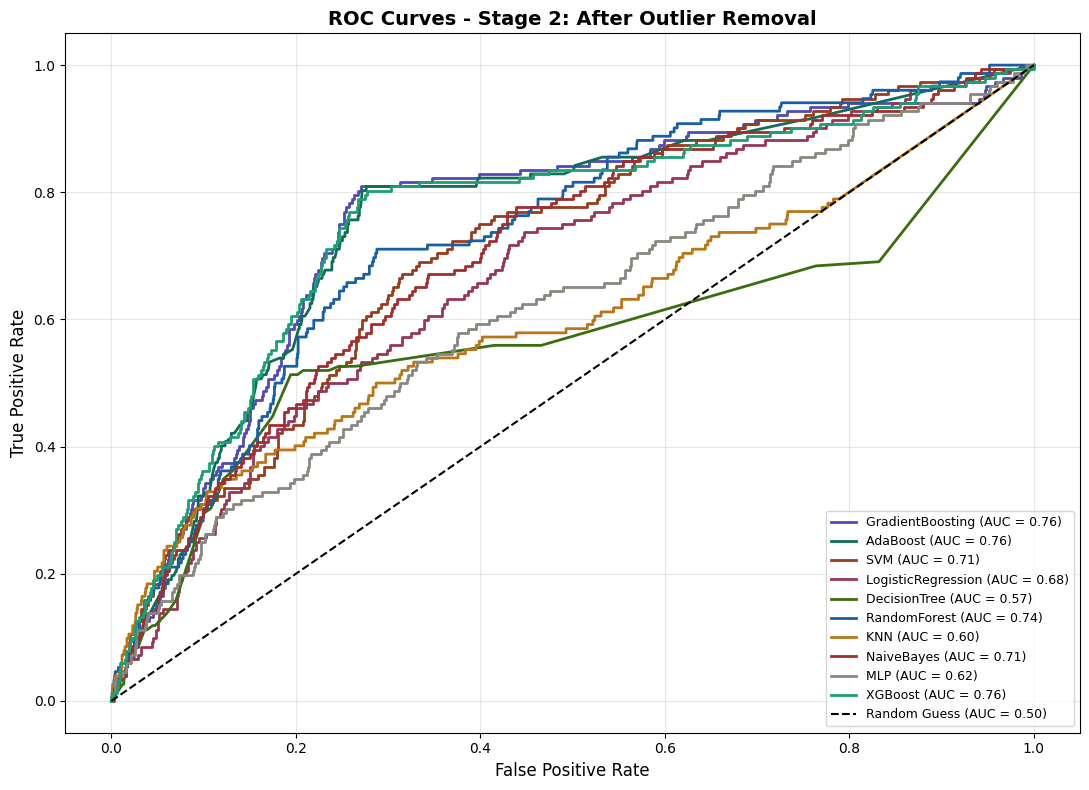

In [17]:
# ── ROC Curves — Stage 2: After Outlier Removal ──
plot_roc(models_s2, x_test_s2, x_test_s2_sc, y_test_s2,
         'ROC Curves - Stage 2: After Outlier Removal')


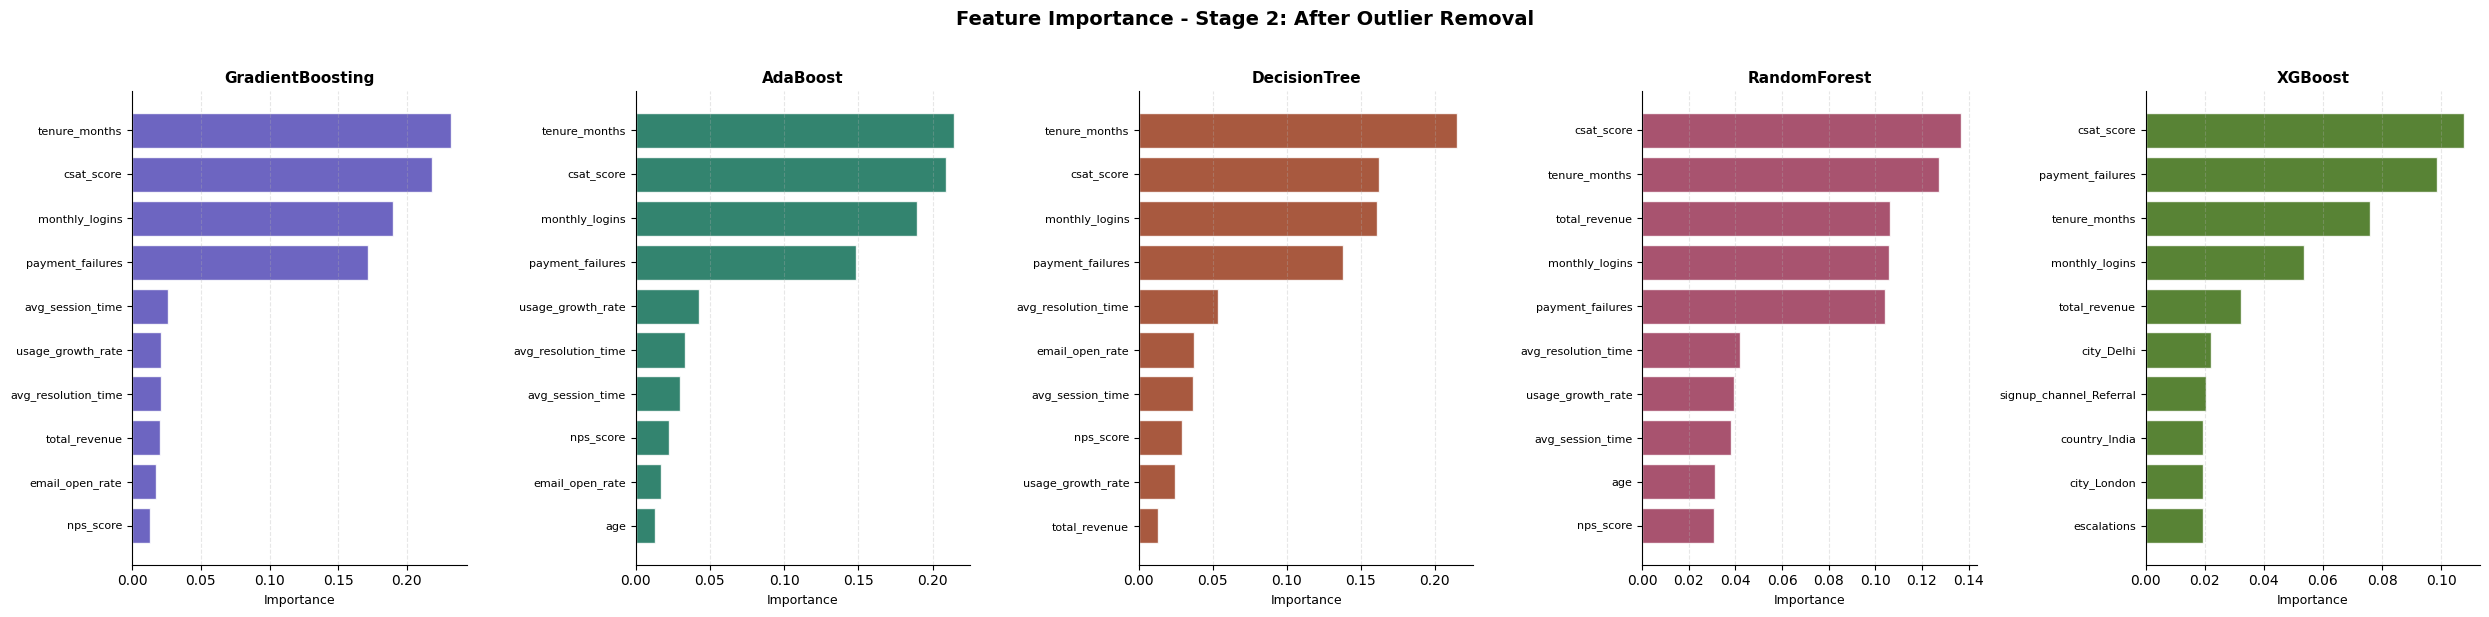

In [18]:
# ── Feature Importance — Stage 2 ──
plot_feature_importance(models_s2, 'Feature Importance - Stage 2: After Outlier Removal')


## 7. Stage 3 — After Feature Selection (Selected 8 Features)

Use only the 8 most relevant features selected from EDA correlation analysis.

In [19]:
# ── Selected features from correlation/EDA analysis ──
selected_features = [
    'tenure_months',
    'csat_score',
    'monthly_logins',
    'payment_failures',
    'last_login_days_ago',
    'avg_session_time',
    'email_open_rate',
    'avg_resolution_time',
]

# Start from clean (outlier-removed) base
data_s3_base = data_raw.copy()
data_s3_base['complaint_type'] = data_s3_base['complaint_type'].fillna('No Complaint')

for col in cat_cols:
    data_s3_base[col] = LabelEncoder().fit_transform(data_s3_base[col].astype(str))

# IQR on selected numeric cols that overlap
for col in col_outliers:
    if col in data_s3_base.columns:
        Q1 = data_s3_base[col].quantile(0.25)
        Q3 = data_s3_base[col].quantile(0.75)
        IQR = Q3 - Q1
        data_s3_base = data_s3_base[
            (data_s3_base[col] >= Q1 - 1.5*IQR) &
            (data_s3_base[col] <= Q3 + 1.5*IQR)
        ]

X_s3 = data_s3_base[selected_features]
y_s3 = data_s3_base['churn']

# Additional IQR on selected features only
mask = ~((X_s3 < (X_s3.quantile(0.25) - 1.5*(X_s3.quantile(0.75)-X_s3.quantile(0.25)))) |
         (X_s3 > (X_s3.quantile(0.75) + 1.5*(X_s3.quantile(0.75)-X_s3.quantile(0.25))))).any(axis=1)
X_s3 = X_s3[mask]
y_s3 = y_s3[mask]

print(f'Stage 3 shape: {X_s3.shape}')
print(f'Selected features: {selected_features}')


Stage 3 shape: (8042, 8)
Selected features: ['tenure_months', 'csat_score', 'monthly_logins', 'payment_failures', 'last_login_days_ago', 'avg_session_time', 'email_open_rate', 'avg_resolution_time']


In [20]:
# ── Train/Test split ──
x_train_s3, x_test_s3, y_train_s3, y_test_s3 = train_test_split(
    X_s3, y_s3, test_size=0.2, random_state=42, stratify=y_s3
)

scaler_s3 = StandardScaler()
x_train_s3_sc = scaler_s3.fit_transform(x_train_s3)
x_test_s3_sc  = scaler_s3.transform(x_test_s3)

pos_weight_s3 = (y_train_s3 == 0).sum() / (y_train_s3 == 1).sum()

print(f'Train: {x_train_s3.shape}  |  Test: {x_test_s3.shape}')
print(f'Churn rate in train: {y_train_s3.mean():.3f}')


Train: (6433, 8)  |  Test: (1609, 8)
Churn rate in train: 0.093


In [21]:
# ── Train & Evaluate — Stage 3 ──
models_s3 = build_models(pos_weight_s3)
models_s3 = train_and_evaluate(
    models_s3, x_train_s3, x_test_s3, y_train_s3, y_test_s3,
    x_train_s3_sc, x_test_s3_sc
)



── GradientBoosting ──
Accuracy: 0.7495
              precision    recall  f1-score   support

    No Churn       0.97      0.75      0.84      1459
       Churn       0.24      0.79      0.37       150

    accuracy                           0.75      1609
   macro avg       0.61      0.77      0.61      1609
weighted avg       0.90      0.75      0.80      1609


── AdaBoost ──
Accuracy: 0.7408
              precision    recall  f1-score   support

    No Churn       0.98      0.73      0.84      1459
       Churn       0.24      0.83      0.37       150

    accuracy                           0.74      1609
   macro avg       0.61      0.78      0.61      1609
weighted avg       0.91      0.74      0.79      1609


── SVM ──
Accuracy: 0.6986
              precision    recall  f1-score   support

    No Churn       0.98      0.68      0.80      1459
       Churn       0.22      0.86      0.35       150

    accuracy                           0.70      1609
   macro avg       0.60   

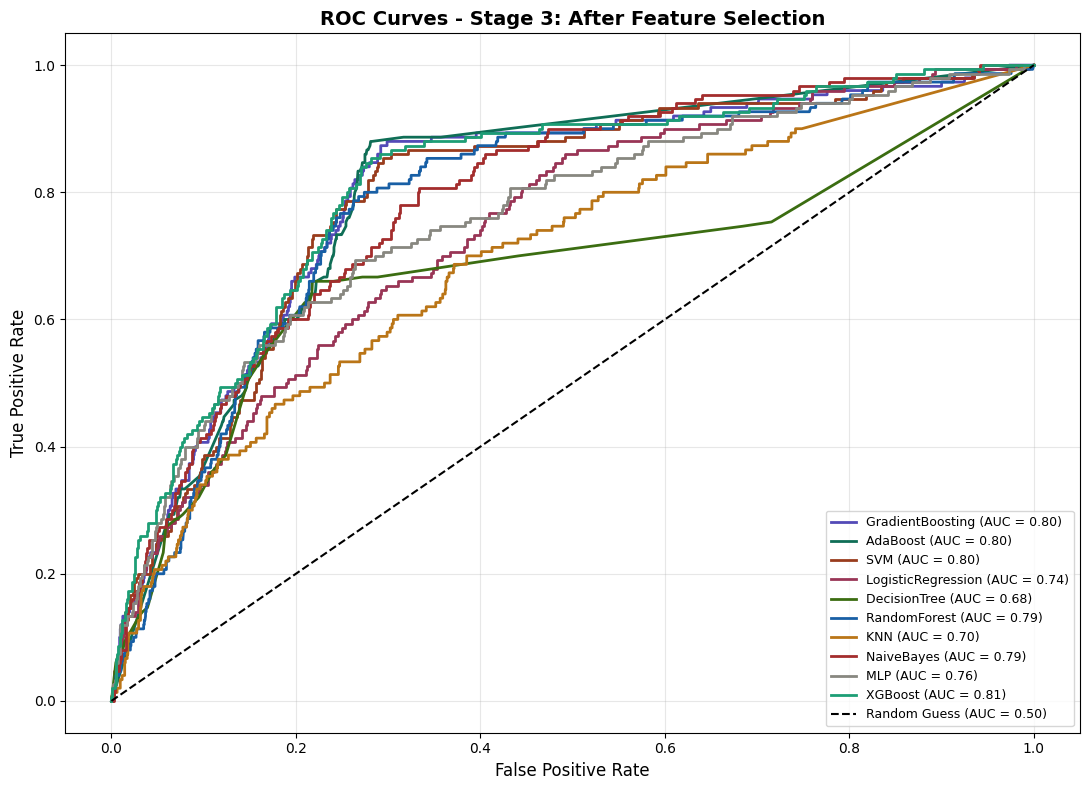

In [22]:
# ── ROC Curves — Stage 3: After Feature Selection ──
plot_roc(models_s3, x_test_s3, x_test_s3_sc, y_test_s3,
         'ROC Curves - Stage 3: After Feature Selection')


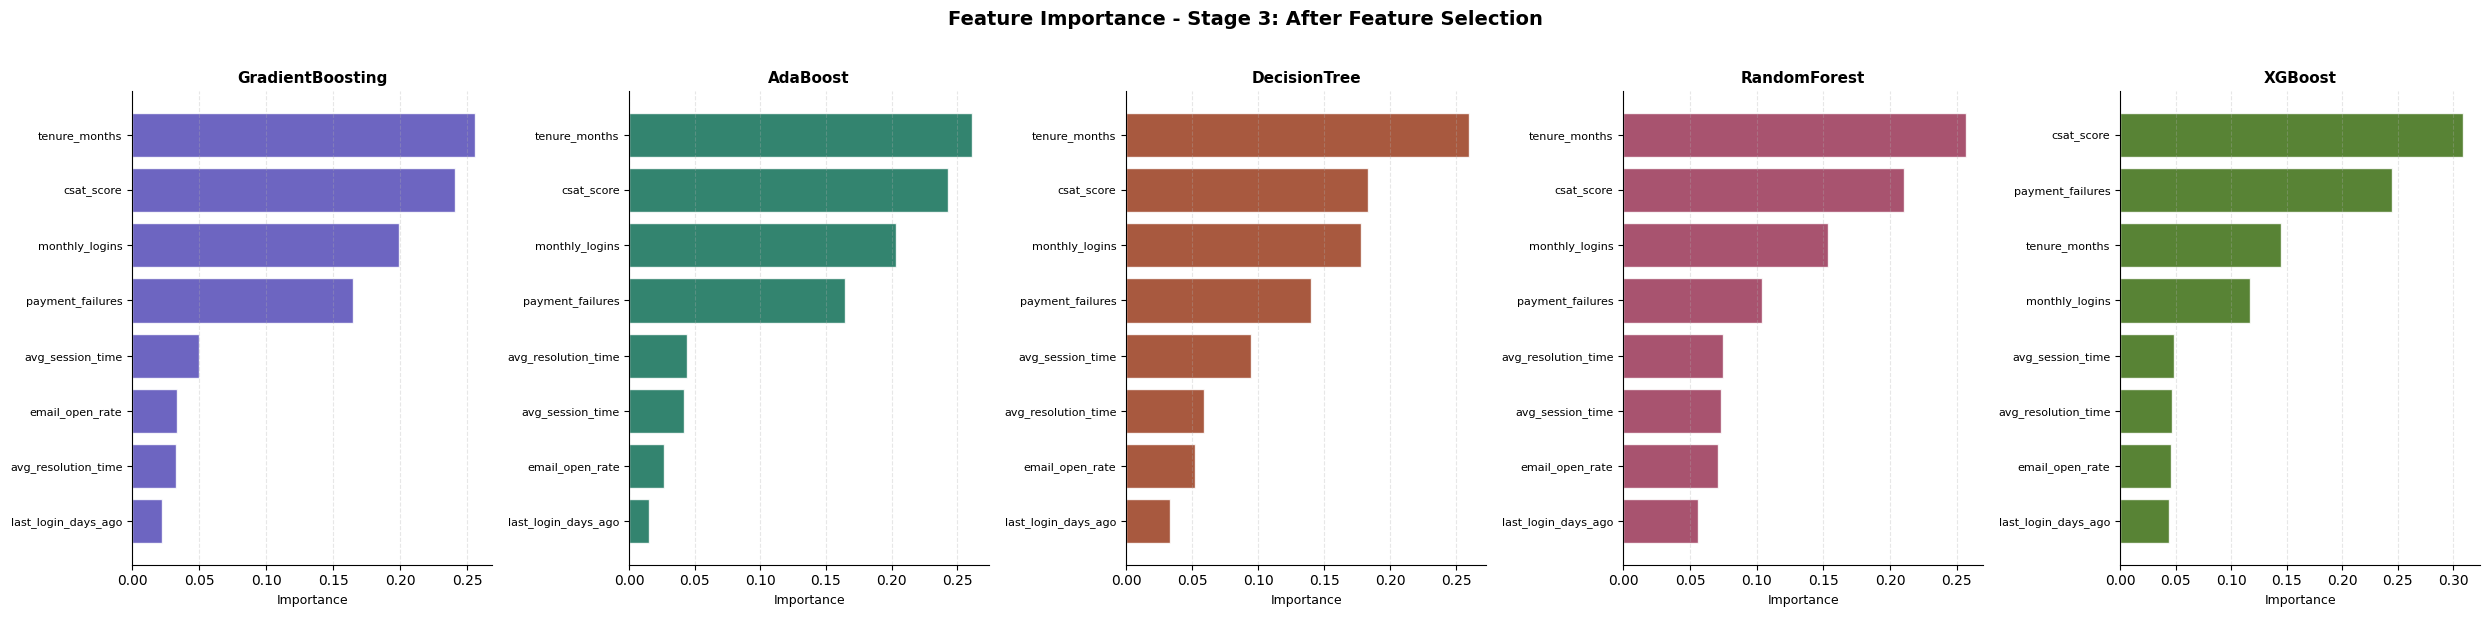

In [23]:
# ── Feature Importance — Stage 3 ──
plot_feature_importance(models_s3, 'Feature Importance - Stage 3: After Feature Selection')


## 8. AUC-ROC Comparison Across All Stages

Summary table comparing AUC-ROC scores for each model across all three pipeline stages.

In [24]:
def get_aucs(models, x_test, x_test_scaled, y_test):
    aucs = {}
    for name, model in models.items():
        x_eval = x_test_scaled if name == 'SVM' else x_test
        y_probs = model.predict_proba(x_eval)[:, 1]
        aucs[name] = round(roc_auc_score(y_test, y_probs), 4)
    return aucs

auc_s1 = get_aucs(models_s1, x_test_s1, x_test_s1_sc, y_test_s1)
auc_s2 = get_aucs(models_s2, x_test_s2, x_test_s2_sc, y_test_s2)
auc_s3 = get_aucs(models_s3, x_test_s3, x_test_s3_sc, y_test_s3)

comparison_df = pd.DataFrame({
    'Stage 1 (Raw)':              auc_s1,
    'Stage 2 (Outliers Removed)': auc_s2,
    'Stage 3 (Feature Selected)': auc_s3,
})
comparison_df['Best Stage'] = comparison_df.idxmax(axis=1)
print('\nAUC-ROC Comparison Across Stages:')
display(comparison_df.sort_values('Stage 3 (Feature Selected)', ascending=False))



AUC-ROC Comparison Across Stages:


,Stage 1 (Raw),Stage 2 (Outliers Removed),Stage 3 (Feature Selected),Best Stage
XGBoost,0.8085,0.7569,0.8136,Stage 3 (Feature Selected)
GradientBoosting,0.8153,0.7579,0.8050,Stage 1 (Raw)
AdaBoost,0.8002,0.7556,0.8040,Stage 3 (Feature Selected)
SVM,0.7537,0.7111,0.7978,Stage 3 (Feature Selected)
NaiveBayes,0.7495,0.7051,0.7899,Stage 3 (Feature Selected)
RandomForest,0.7813,0.7353,0.7872,Stage 3 (Feature Selected)
MLP,0.6846,0.6197,0.7606,Stage 3 (Feature Selected)
LogisticRegression,0.7210,0.6762,0.7426,Stage 3 (Feature Selected)
KNN,0.6312,0.6019,0.6962,Stage 3 (Feature Selected)
DecisionTree,0.6298,0.5712,0.6796,Stage 3 (Feature Selected)


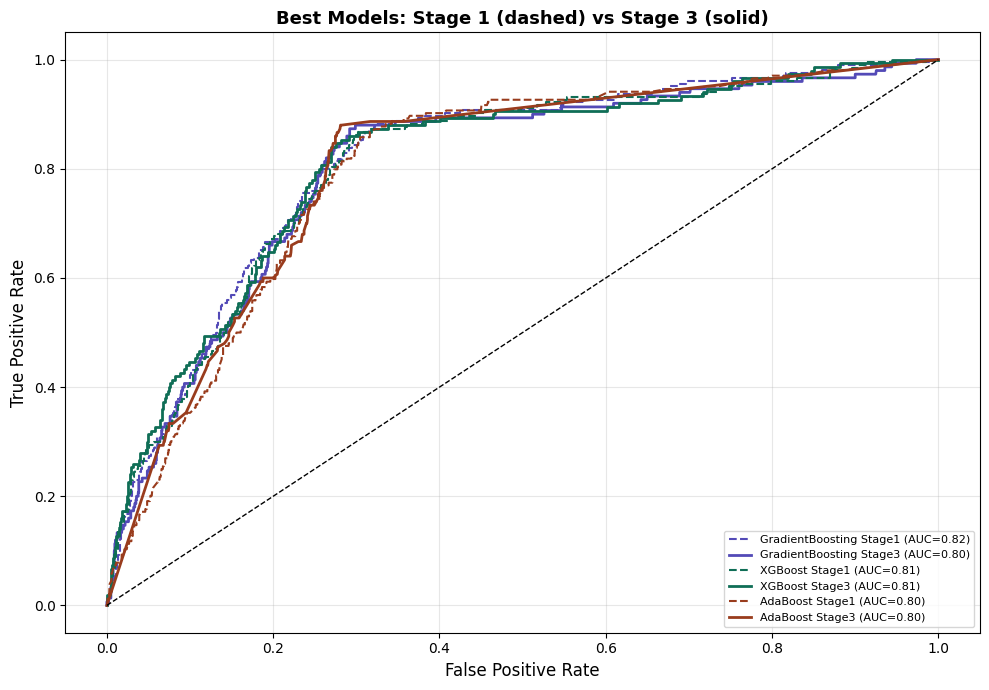

In [25]:
# ── Combined ROC comparison plot (Stage 1 vs Stage 3) for best models ──
best_models = ['GradientBoosting', 'XGBoost', 'AdaBoost']
colors_s1 = ['#534AB7', '#0F6E56', '#993C1D']
colors_s3 = ['#AFA9EC', '#5DCAA5', '#F0997B']

plt.figure(figsize=(10, 7))
for name, c1, c3 in zip(best_models, colors_s1, colors_s3):
    # Stage 1
    y_p1 = models_s1[name].predict_proba(x_test_s1)[:, 1]
    fpr1, tpr1, _ = roc_curve(y_test_s1, y_p1)
    auc1 = roc_auc_score(y_test_s1, y_p1)
    plt.plot(fpr1, tpr1, '--', color=c1, linewidth=1.5,
             label=f'{name} Stage1 (AUC={auc1:.2f})')
    # Stage 3
    y_p3 = models_s3[name].predict_proba(x_test_s3)[:, 1]
    fpr3, tpr3, _ = roc_curve(y_test_s3, y_p3)
    auc3 = roc_auc_score(y_test_s3, y_p3)
    plt.plot(fpr3, tpr3, '-', color=c1, linewidth=2,
             label=f'{name} Stage3 (AUC={auc3:.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Best Models: Stage 1 (dashed) vs Stage 3 (solid)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_stage1_vs_stage3.png', dpi=150, bbox_inches='tight')
plt.show()
